In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print("Libraries imported successfully!")

Saving Loan_Approval_Dataset.csv to Loan_Approval_Dataset (1).csv
Upload completed: ['Loan_Approval_Dataset (1).csv']


In [3]:
# Load dataset
FILE_NAME = 'Loan_Approval_Dataset.csv'
data = pd.read_csv(FILE_NAME)

print('=' * 60)
print('LOAN APPROVAL DATASET - EDA')
print('=' * 60)
display(data.head())
print('\nDataset shape:', data.shape)
print('\nColumns:', data.columns.tolist())
print('\nData types:')
print(data.dtypes)


LOAN APPROVAL DATASET - EDA


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP00001,Male,Yes,0,Graduate,No,3435,0,186,360,1.0,Urban,Y
1,LP00002,Female,Yes,0,Not Graduate,No,1171,2515,117,360,1.0,Rural,Y
2,LP00003,Male,No,3+,Graduate,No,3837,4993,267,360,1.0,Rural,Y
3,LP00004,Male,No,0,Graduate,No,8502,2135,334,360,1.0,Urban,N
4,LP00005,Male,No,0,Graduate,No,6785,0,265,360,1.0,Urban,Y



Dataset shape: (1000, 13)

Columns: ['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']

Data types:
Loan_ID                  str
Gender                   str
Married                  str
Dependents               str
Education                str
Self_Employed            str
ApplicantIncome        int64
CoapplicantIncome      int64
LoanAmount             int64
Loan_Amount_Term       int64
Credit_History       float64
Property_Area            str
Loan_Status              str
dtype: object


In [4]:
# Dataset information and descriptive statistics
print('DATASET INFORMATION')
data.info()

print('\nSTATISTICAL SUMMARY')
display(data.describe(include='all').T)

DATASET INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            1000 non-null   str    
 1   Gender             980 non-null    str    
 2   Married            979 non-null    str    
 3   Dependents         984 non-null    str    
 4   Education          1000 non-null   str    
 5   Self_Employed      978 non-null    str    
 6   ApplicantIncome    1000 non-null   int64  
 7   CoapplicantIncome  1000 non-null   int64  
 8   LoanAmount         1000 non-null   int64  
 9   Loan_Amount_Term   1000 non-null   int64  
 10  Credit_History     983 non-null    float64
 11  Property_Area      1000 non-null   str    
 12  Loan_Status        1000 non-null   str    
dtypes: float64(1), int64(4), str(8)
memory usage: 135.0 KB

STATISTICAL SUMMARY


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Loan_ID,1000,1000,LP00001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,980,2,Male,741,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Married,979,2,Yes,616,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,984,4,0,544,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education,1000,2,Graduate,789,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Self_Employed,978,2,No,836,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ApplicantIncome,1000.0,NaN,NaN,NaN,5671.538,3594.096882,730.0,3262.5,4879.0,7186.5,32572.0
CoapplicantIncome,1000.0,NaN,NaN,NaN,1806.704,2410.907652,0.0,0.0,1139.0,2685.0,21350.0
LoanAmount,1000.0,NaN,NaN,NaN,253.849,115.365825,46.0,171.0,235.5,311.0,700.0
Loan_Amount_Term,1000.0,NaN,NaN,NaN,325.368,76.978063,84.0,360.0,360.0,360.0,480.0


,Missing Values,Percentage
Self_Employed,22,2.2
Married,21,2.1
Gender,20,2.0
Credit_History,17,1.7
Dependents,16,1.6


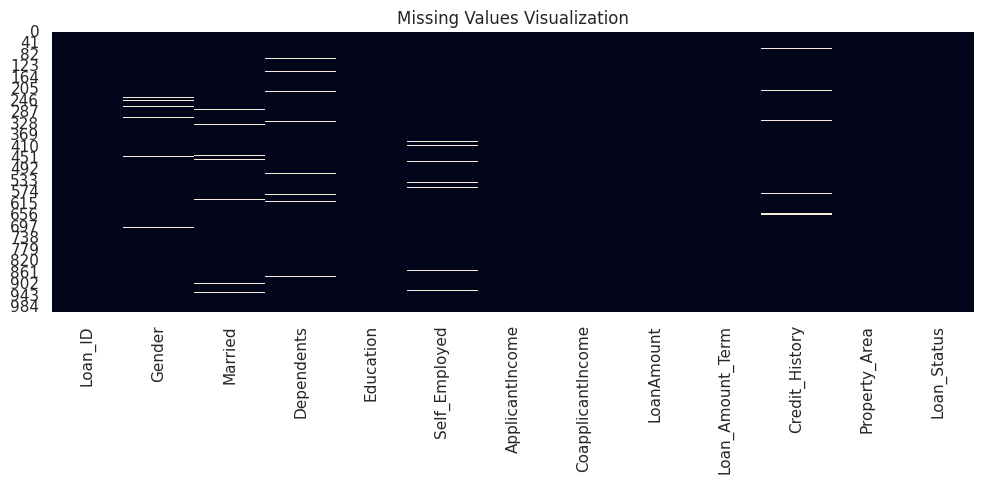

In [5]:
# Missing values analysis
missing = data.isnull().sum().sort_values(ascending=False)
missing_percent = (missing / len(data) * 100).round(2)
missing_table = pd.DataFrame({'Missing Values': missing, 'Percentage': missing_percent})
display(missing_table[missing_table['Missing Values'] > 0])

plt.figure(figsize=(10, 5))
sns.heatmap(data.isnull(), cbar=False)
plt.title('Missing Values Visualization')
plt.tight_layout()
plt.show()

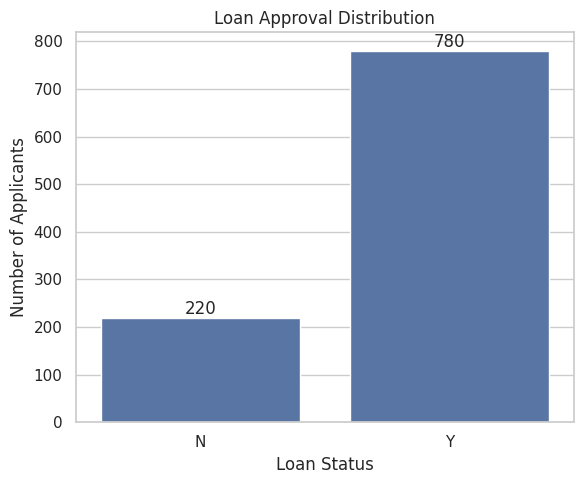

Loan_Status
Y    780
N    220
Name: count, dtype: int64

Percentage distribution:
Loan_Status
Y    78.0
N    22.0
Name: proportion, dtype: float64


In [6]:
# Target variable distribution
plt.figure(figsize=(6, 5))
ax = sns.countplot(data=data, x='Loan_Status', order=sorted(data['Loan_Status'].dropna().unique()))
plt.title('Loan Approval Distribution')
plt.xlabel('Loan Status')
plt.ylabel('Number of Applicants')
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.show()

print(data['Loan_Status'].value_counts())
print('\nPercentage distribution:')
print((data['Loan_Status'].value_counts(normalize=True) * 100).round(2))

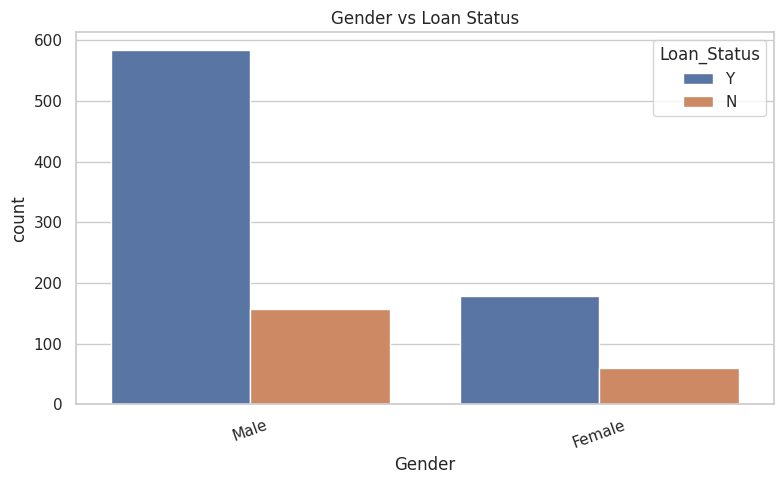

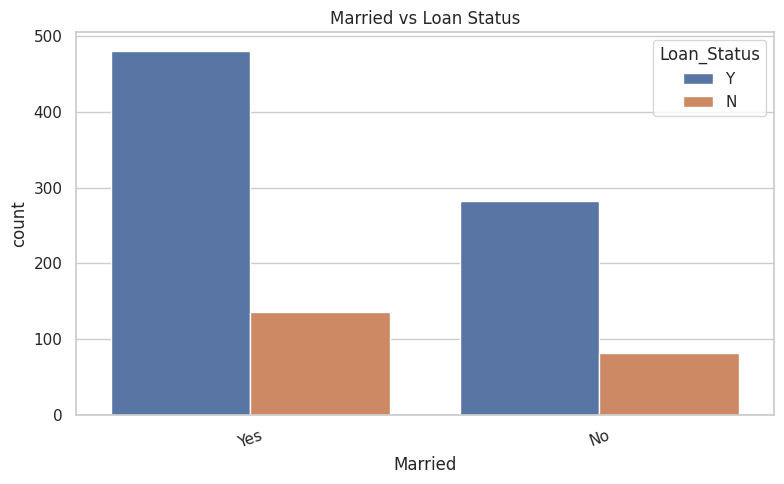

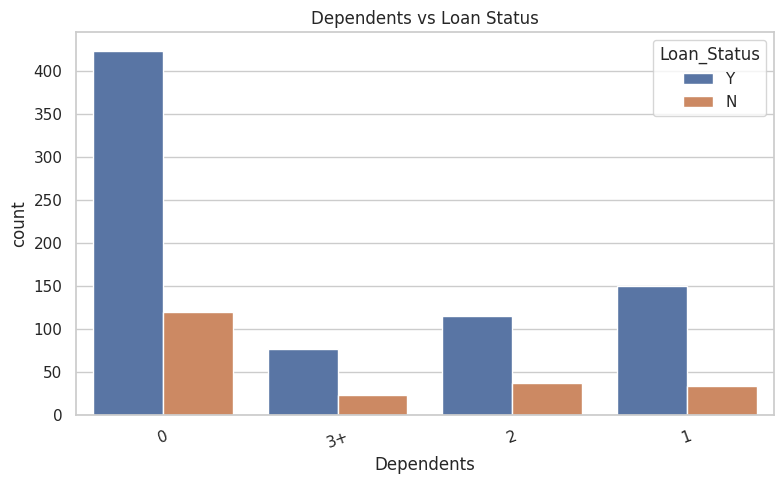

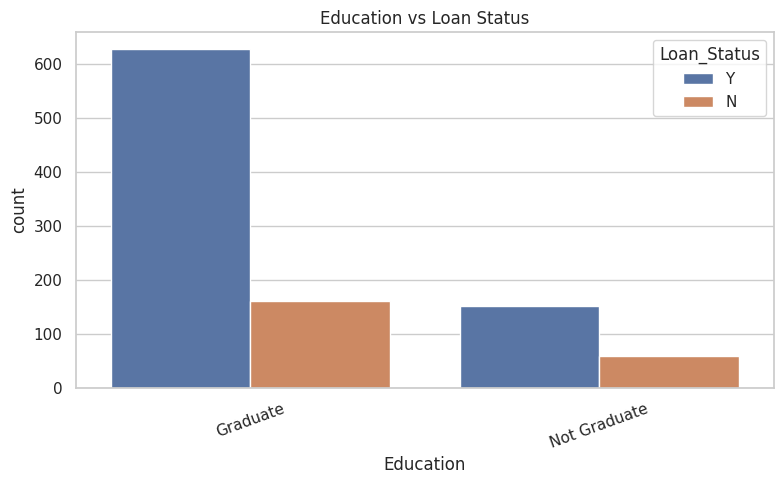

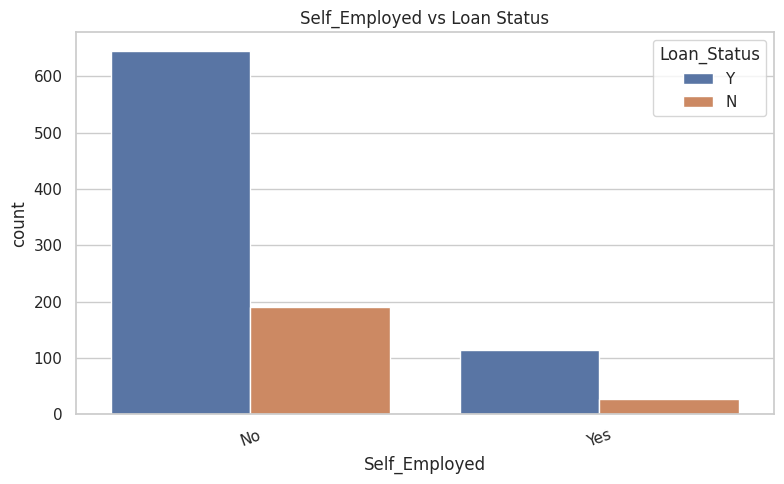

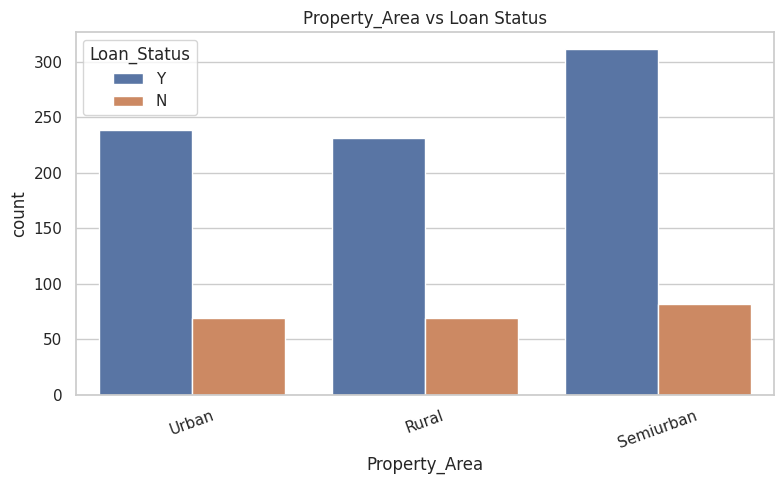

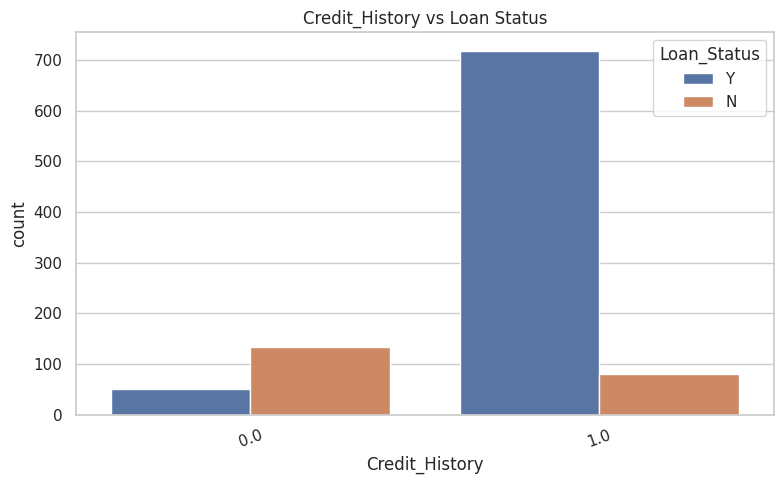

In [7]:
# Categorical features vs Loan Status
categorical_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Credit_History']

for col in categorical_cols:
    if col in data.columns:
        plt.figure(figsize=(8, 5))
        sns.countplot(data=data, x=col, hue='Loan_Status')
        plt.title(f'{col} vs Loan Status')
        plt.xticks(rotation=20)
        plt.tight_layout()
        plt.show()

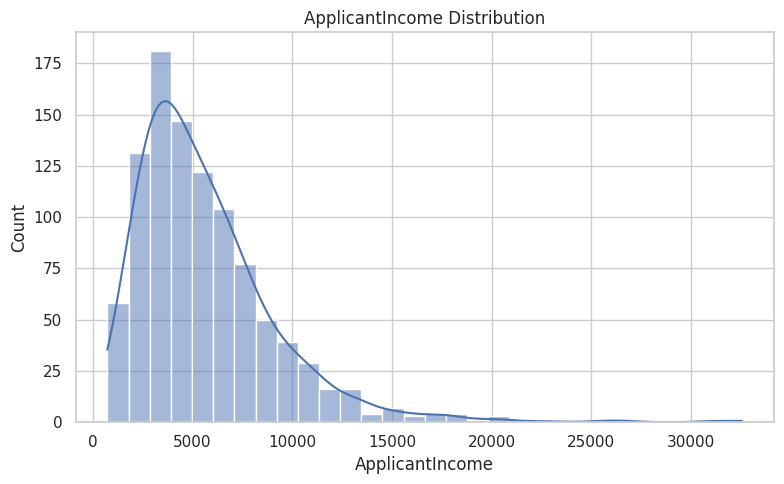

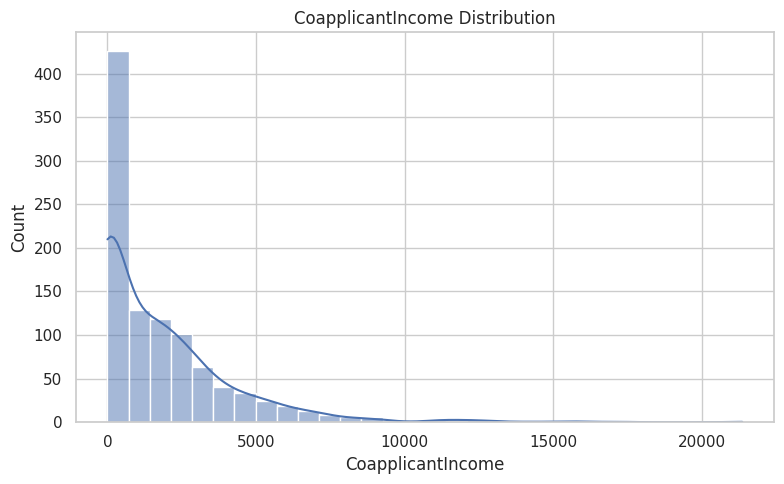

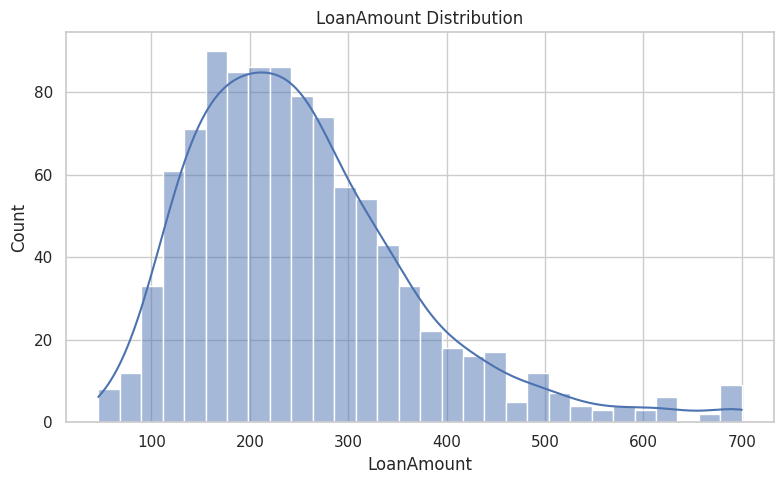

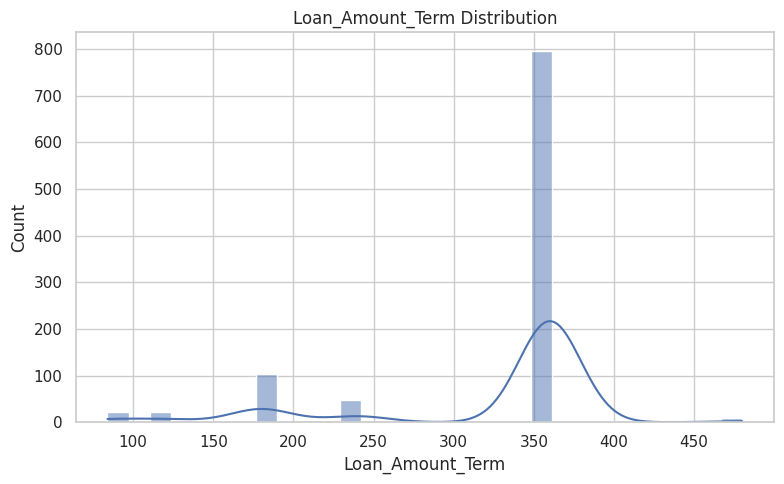

In [8]:
# Numerical feature distributions
numerical_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']

for col in numerical_cols:
    if col in data.columns:
        plt.figure(figsize=(8, 5))
        sns.histplot(data=data, x=col, kde=True, bins=30)
        plt.title(f'{col} Distribution')
        plt.tight_layout()
        plt.show()

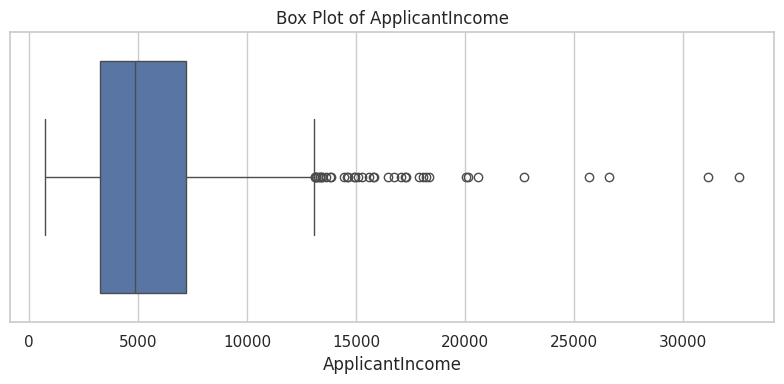

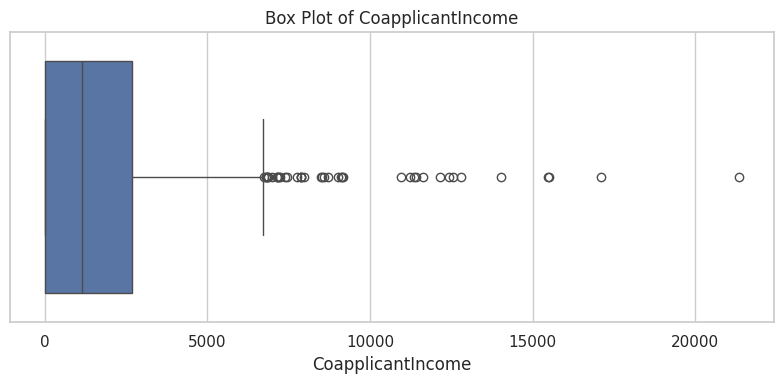

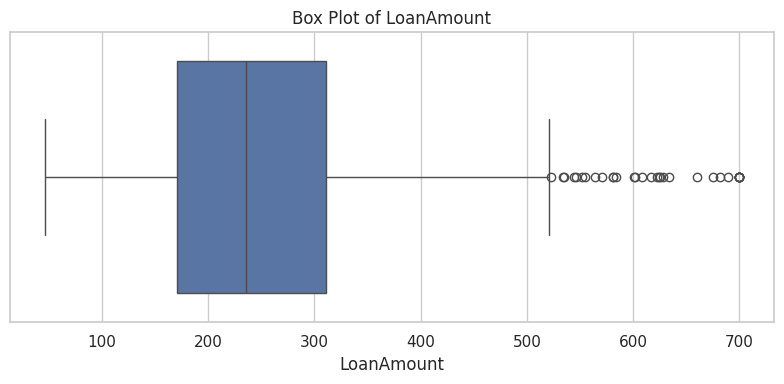

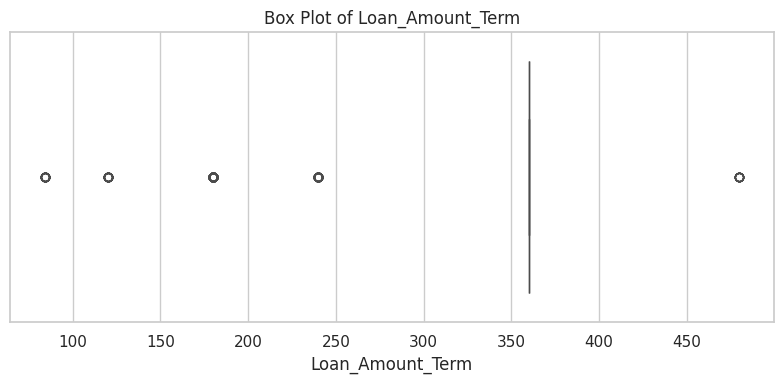

In [9]:
# Outlier analysis using box plots
for col in numerical_cols:
    if col in data.columns:
        plt.figure(figsize=(8, 4))
        sns.boxplot(data=data, x=col)
        plt.title(f'Box Plot of {col}')
        plt.tight_layout()
        plt.show()

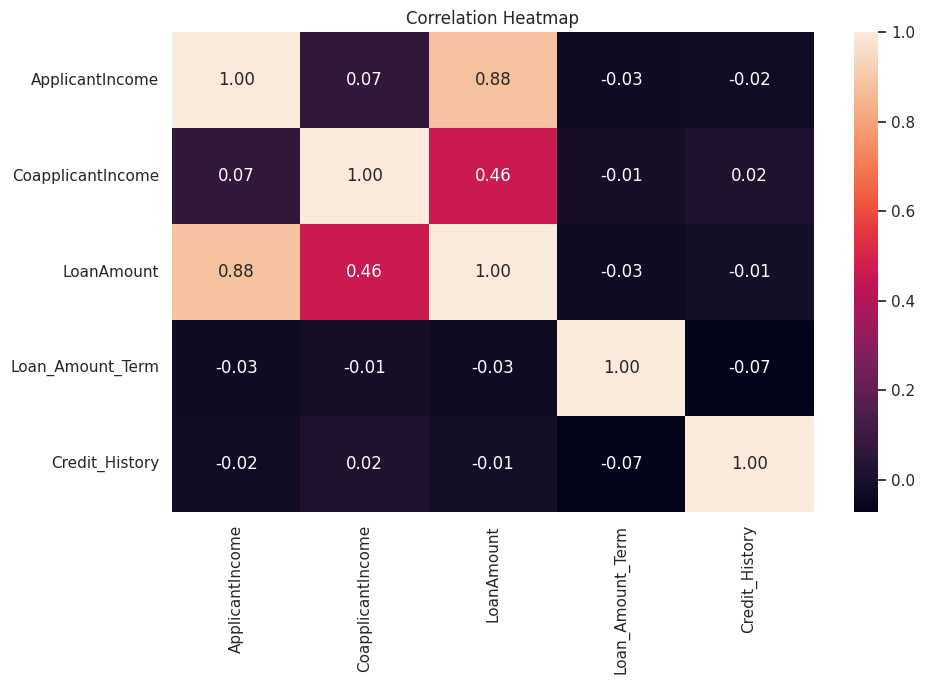

In [10]:
# Correlation heatmap
numerical_data = data.select_dtypes(include=np.number)

plt.figure(figsize=(10, 7))
sns.heatmap(numerical_data.corr(), annot=True, fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

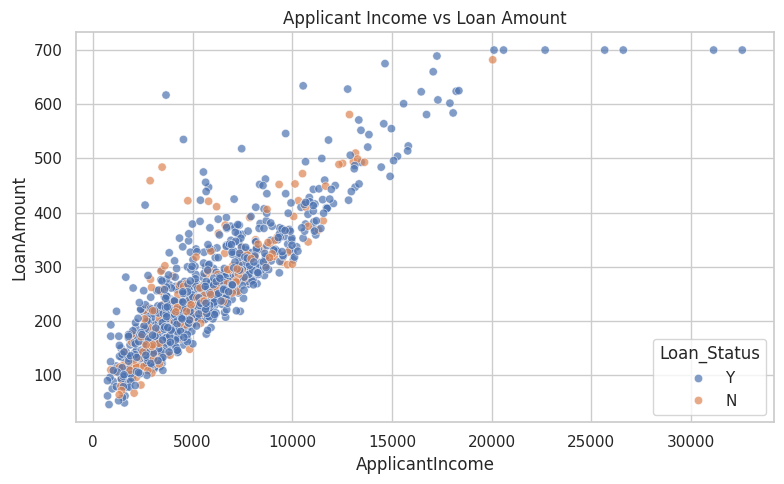

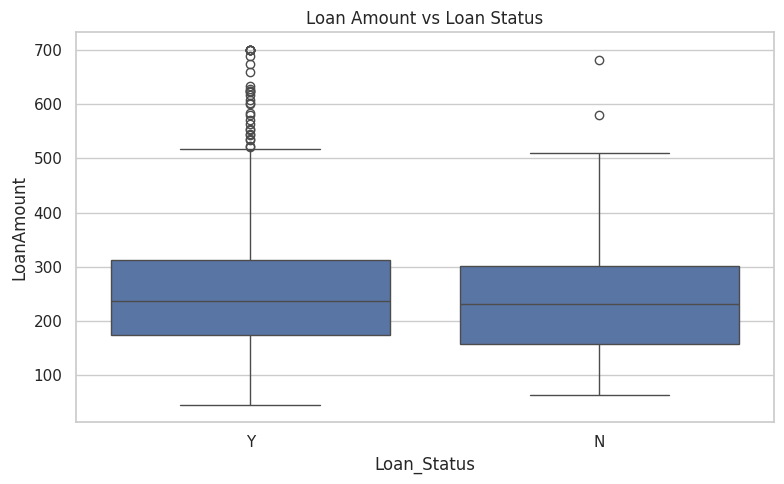

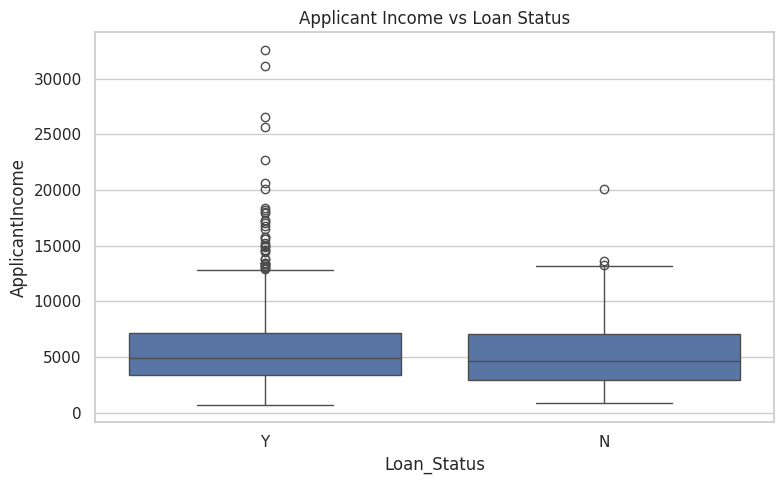

In [11]:
# Important feature relationships
plt.figure(figsize=(8, 5))
sns.scatterplot(data=data, x='ApplicantIncome', y='LoanAmount', hue='Loan_Status', alpha=0.7)
plt.title('Applicant Income vs Loan Amount')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(data=data, x='Loan_Status', y='LoanAmount')
plt.title('Loan Amount vs Loan Status')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(data=data, x='Loan_Status', y='ApplicantIncome')
plt.title('Applicant Income vs Loan Status')
plt.tight_layout()
plt.show()

In [12]:
# Final EDA summary generated from the dataset
print('=' * 60)
print('EDA COMPLETED SUCCESSFULLY')
print('=' * 60)
print(f'Total records: {data.shape[0]}')
print(f'Total columns: {data.shape[1]}')
print(f'Target variable: Loan_Status')
print(f'Total missing values: {int(data.isnull().sum().sum())}')
print('\nApproval distribution:')
print(data['Loan_Status'].value_counts())
print('\nNext step: use this cleaned/understood dataset for preprocessing and ensemble model training.')

EDA COMPLETED SUCCESSFULLY
Total records: 1000
Total columns: 13
Target variable: Loan_Status
Total missing values: 96

Approval distribution:
Loan_Status
Y    780
N    220
Name: count, dtype: int64

Next step: use this cleaned/understood dataset for preprocessing and ensemble model training.
